- 언어 모델이란 단어 시퀀스(문장)에 확률을 할당(assign)하는 모델임
- 통계적 언어 모델`SLM`과 인공신경망 언어 모델`NLM`로 나뉘어짐

## 1. 언어 모델(Language Model)
- 가장 보편적인 언어 모델은 이전 단어들이 주어졌을 때 다음 단어를 예측하도록 하는 방법
- 다른 유형으로는 주어진 양쪽의 단어들로부터 가운데 비어있는 단어를 예측하는 방법(`BERT` 등)이 있음

## 2. 단어 시퀀스의 확률 할당
- 주어진 상황에서 각 단어 시퀀스(문장)의 확률을 할당하면, 가장 적합한 문장을 고를 수 있음
- 이를 통해 기계번역, 오타교정, 음성인식 등의 작업이 가능

## 3. 단어 시퀀스의 확률
### 3.1 조건부확률 $ P(B|A) $의 성질과 연쇄 법칙(Chain Rule)
$$
\begin{align*}
P(B|A) &= \frac{P(A \cap B)}{P(A)}\\
P(A \cap B) &= P(A) \times P(B|A)\\
\end{align*}
$$

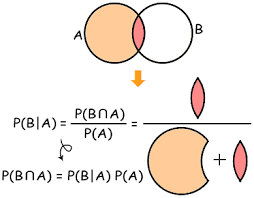

$$
\begin{align*}
P(\bigcap_{k=1}^n x_k) &= P(x_1) \times P(x_2|x_1) \times .. \times P(x_n|\bigcap_{k=1}^{n-1} x_k) \\
&= \prod_{i=1}^n P(x_i | \bigcap_{k=1}^{n-1} x_k) \\
\end{align*}
$$

### 3.2 문장에 대한 확률
각각의 단어를 $w_i$, n개의 단어로 구성된 시퀀스(문장)를 $W$이라 할 때,

$$
\begin{align*}
P(W_n)
 &= P(\bigcap_{k=1}^n w_k)\\
 &= \prod_{i=1}^n P(w_i | \bigcap_{k=1}^{n-1} w_k)\\
 &= \prod_{i=1}^n P(w_i | W_{i-1})\\
 &= \prod_{i=1}^n \frac{P(w_i \cap W_{i-1})}{P(W_{i-1})}\\
 &= \prod_{i=1}^n \frac{P(W_i)}{P(W_{i-1})}\\
\end{align*}
$$

## 4. 통계적 언어 모델`SLM`의 접근: 카운트 기반
$n-1$개의 단어로 이루어진 문장 $W_{n-1}$의 다음 단어로 $w_n$이 나올 확률은
$$
P(w_n|W_{n-1})= \frac{\text{Count}(w_n \cap W_{n-1})}{\text{Count}{(W_{n-1})}}\\
$$
- 학습한 코퍼스에서 각각의 경우에 해당하는 데이터의 등장횟수를 세어 구함
- 그러나, 이런 방식으로 학습하기 위해서는 문장의 길이가 짧거나 코퍼스의 크기가 매우 커야 함
    - n-1번째까지 일치하는 문장이 없을 경우 확률이 정의되지 않음
    - n번째까지 일치하는 문장이 없을 경우 확률이 0이 됨
    - 언어의 기본 속성이 생성문법임을 생각할 때, 이러한 방식은 한계가 큼
    - 이를 희소 문제`Sparsity Problem`라고 함
